# 🍄 FungiCLEF 2025 — CAFormer (MetaFormer) Multitask Classifier
**Backbone:** `caformer_s18.sail_in22k` (MetaFormer, ImageNet-22K pretrained)  
**Tasks:** Species classification (2427 classes) + Toxicity prediction

In [1]:
import os
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from PIL import Image
from torchvision import transforms
import timm
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

In [2]:
IMG_MEAN  = [0.485, 0.456, 0.406]
IMG_STD   = [0.229, 0.224, 0.225]
IMG_SIZE  = 224
SPLIT_MAP = {'train': 'Train', 'val': 'Val', 'test': 'Test'}

class FungiDataset(Dataset):
    """FungiTastic-FewShot dataset (FungiCLEF 2025).

    Labeled splits (train/val): returns (image, category_id, poisonous, filename)
    Test split:                  returns (image, filename, observationID)
    """
    def __init__(self, data_root, split='train', transform=None):
        self.split   = split
        self.img_dir = os.path.join(data_root, 'images', 'FungiTastic-FewShot',
                                    split, '300p')
        csv_name = f'FungiTastic-FewShot-{SPLIT_MAP[split]}.csv'
        self.df  = pd.read_csv(os.path.join(data_root, 'metadata',
                               'FungiTastic-FewShot', csv_name))

        if transform is not None:
            self.transform = transform
        elif split == 'train':
            self.transform = transforms.Compose([
                transforms.Resize((IMG_SIZE, IMG_SIZE)),
                transforms.RandomHorizontalFlip(),
                transforms.RandomVerticalFlip(),
                transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
                transforms.RandomRotation(15),
                transforms.ToTensor(),
                transforms.Normalize(IMG_MEAN, IMG_STD),
            ])
        else:
            self.transform = transforms.Compose([
                transforms.Resize((IMG_SIZE, IMG_SIZE)),
                transforms.ToTensor(),
                transforms.Normalize(IMG_MEAN, IMG_STD),
            ])

        self.has_labels = 'category_id' in self.df.columns
        if self.has_labels:
            self.df['category_id'] = self.df['category_id'].astype(int)
            self.df['poisonous']   = self.df['poisonous'].astype(int)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(os.path.join(self.img_dir, row['filename'])).convert('RGB')
        img = self.transform(img)
        if self.has_labels:
            return img, int(row['category_id']), int(row['poisonous']), row['filename']
        return img, row['filename'], str(row['observationID'])


def fungi_collate_fn(batch):
    imgs, cids, tox, fns = zip(*batch)
    return (torch.stack(imgs),
            torch.tensor(cids, dtype=torch.long),
            torch.tensor(tox,  dtype=torch.long),
            list(fns))

def fungi_collate_test(batch):
    imgs, fns, obs = zip(*batch)
    return torch.stack(imgs), list(fns), list(obs)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Legacy preprocessing helpers removed — PIL pipeline used instead.

In [4]:
# Old FungiDataset (cv2-based) removed — new PIL-based class defined in Cell 2.

In [5]:
DATA_ROOT  = 'data'
BATCH_SIZE = 32
NUM_EPOCHS = 30

NUM_CLASSES = 2427   # category_id 0-2426
NUM_TOX     = 2      # 0 = non-poisonous, 1 = poisonous

train_dataset = FungiDataset(DATA_ROOT, 'train')
val_dataset   = FungiDataset(DATA_ROOT, 'val')
test_dataset  = FungiDataset(DATA_ROOT, 'test')

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=4, collate_fn=fungi_collate_fn,
                          pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=4, collate_fn=fungi_collate_fn,
                          pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=4, collate_fn=fungi_collate_test,
                          pin_memory=True)

print(f"Train : {len(train_dataset):5d} images | {len(train_loader):3d} batches")
print(f"Val   : {len(val_dataset):5d} images | {len(val_loader):3d} batches")
print(f"Test  : {len(test_dataset):5d} images | {len(test_loader):3d} batches")

Length of train_loader: 322 and val_loader: 80


In [6]:
import torch.optim as optim

num_species_classes  = NUM_CLASSES   # 2427
num_toxicity_classes = NUM_TOX       # 2

# ── CAFormer backbone (MetaFormer, ImageNet-22K pretrained) ───────────────
base_model = timm.create_model(
    'caformer_s18.sail_in22k',
    pretrained=True,
    num_classes=num_species_classes
)
base_model.to(device)

class MultiTaskModel(nn.Module):
    def __init__(self, base_model, num_species_classes, num_toxicity_classes):
        super(MultiTaskModel, self).__init__()
        self.base_model = base_model
        self.base_model.reset_classifier(num_species_classes)
        num_features = base_model.num_features
        self.fc_toxicity = nn.Linear(num_features, num_toxicity_classes)
        self.global_pool = nn.AdaptiveAvgPool2d(1)

    def forward(self, x):
        features        = self.base_model.forward_features(x)
        species_logits  = self.base_model.forward_head(features)
        pooled_features = self.global_pool(features).flatten(1)
        toxicity_logits = self.fc_toxicity(pooled_features)
        return {'species': species_logits, 'toxicity': toxicity_logits}

model = MultiTaskModel(base_model, num_species_classes, num_toxicity_classes)
model.to(device)

# Weighted toxicity loss — handles extreme imbalance (7 762 non-pois vs 57 pois)
tox_weight = torch.tensor([1.0, 7762.0 / 57.0], dtype=torch.float).to(device)

# Differential learning rates: backbone fine-tuned slowly, heads trained faster
optimizer = optim.AdamW([
    {'params': model.base_model.parameters(),      'lr': 5e-5},   # pretrained backbone
    {'params': model.fc_toxicity.parameters(),     'lr': 5e-4},   # new toxicity head
], weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

criterion_species  = nn.CrossEntropyLoss()
criterion_toxicity = nn.CrossEntropyLoss(weight=tox_weight)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters : {n_params:,}")
print(f"CAFormer feature dim : {base_model.num_features}")
print(f"Backbone LR: 5e-5  |  Head LR: 5e-4")

Number of species classes: 100


/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


MultiTaskModel(
  (base_model): MetaFormer(
    (stem): Stem(
      (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(4, 4), padding=(2, 2))
      (norm): LayerNorm2dNoBias((64,), eps=1e-06, elementwise_affine=True)
    )
    (stages): Sequential(
      (0): MetaFormerStage(
        (downsample): Identity()
        (blocks): Sequential(
          (0): MetaFormerBlock(
            (norm1): LayerNorm2dNoBias((64,), eps=1e-06, elementwise_affine=True)
            (token_mixer): SepConv(
              (pwconv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
              (act1): StarReLU(
                (relu): ReLU()
              )
              (dwconv): Conv2d(128, 128, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=128, bias=False)
              (act2): Identity()
              (pwconv2): Conv2d(128, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
            )
            (drop_path1): Identity()
            (layer_scale1): Identity()
            (res_

In [7]:
images, class_ids, toxicities, filenames = next(iter(train_loader))

print(f"Image tensor : {images.shape}  dtype={images.dtype}")
print(f"Class IDs    : min={class_ids.min()}, max={class_ids.max()}")
print(f"Toxicities   : {toxicities.unique().tolist()}")
print(f"Filename[0]  : {filenames[0]}")

assert class_ids.min() >= 0 and class_ids.max() < num_species_classes
print("Batch OK ✓")

Class IDs in batch: tensor([51, 18, 17, 29,  6, 27,  2, 98, 97,  1, 55, 90, 17, 11, 58, 44, 79, 13,
        69, 36, 72, 41, 39, 21, 84, 59, 62, 18, 49, 55, 28, 77, 62, 93, 89, 36,
        72,  6, 59, 80, 94, 72, 90, 62, 96, 14, 78, 94, 12, 90, 95, 88, 17,  2,
         1, 77, 54, 35, 52, 25,  4, 10, 37, 31])
Min class ID: 1, Max class ID: 98


In [35]:
def conf_matrix(targets, predictions, task_name, matrix_type='species', colors=None):
    """
    Compute and plot a confusion matrix with customizable display and colors.

    Args:
        targets: True labels.
        predictions: Predicted labels.
        task_name: Name of the task (e.g., 'Species', 'Toxicity').
        matrix_type: Type of matrix ('species' or 'toxicity') for specific display logic.
        colors: Custom color palette.
    """
    from sklearn.metrics import confusion_matrix
    import seaborn as sns
    import matplotlib.pyplot as plt
    import numpy as np

    # Compute confusion matrix
    cm = confusion_matrix(targets, predictions)

    if matrix_type == 'species':
        # For Species Misclassification Matrix
        plt.figure(figsize=(6, 1))  # Wide and short, single row
        sns.set(font_scale=1.4)

        # Define colors: Red for misclassified, Green for recognized
        cmap = sns.color_palette(['green', 'red']) if not colors else sns.color_palette(colors)

        sns.heatmap(
            cm[:1],  # Only show the first row
            annot=True,
            fmt='d',
            cmap=cmap,
            cbar=False,
            xticklabels=['Missclassified', 'Recognized'],  # Bottom labels
            yticklabels=[]  # Remove true labels from the side
        )
        plt.xlabel('Predicted')
        plt.title(f'{task_name} Misclassification Matrix')
        plt.show()

    if matrix_type == 'toxicity':
        # For Toxicity Matrix
        plt.figure(figsize=(6, 5))
        sns.set(font_scale=1.4)

        # Assign unique indices to each cell type
        cell_type_indices = np.array([[0, 1], [2, 3]])  # TN, FP, FN, TP

        # Define custom colors for each cell type
        if colors is None:
            colors = ['black', 'yellow', 'purple', 'black']  # TN, FP, FN, TP

        # Create a custom colormap from the specified colors
        custom_cmap = ListedColormap(colors)

        # Plot the heatmap using the cell_type_indices to map colors
        sns.heatmap(
            cell_type_indices,
            annot=cm,
            fmt='d',
            cmap=custom_cmap,
            cbar=False,
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive']
        )
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.title(f'{task_name} Classification Confusion Matrix')
        plt.show()

    return cm

In [36]:
def train_model(model, train_loader, val_loader, optimizer, scheduler=None,
                num_epochs=30, alpha=1.0, beta=0.3):
    train_losses, val_losses = [], []
    train_accuracies_species,  train_accuracies_toxicity  = [], []
    val_accuracies_species,    val_accuracies_toxicity    = [], []
    best_val_acc = 0.0
    scaler = torch.amp.GradScaler('cuda', enabled=(device.type == 'cuda'))

    print(f"{'Epoch':>5} {'TLoss':>7} {'VLoss':>7} "
          f"{'T-Sp%':>7} {'V-Sp%':>7} {'T-Tox%':>7} {'V-Tox%':>7}  LR")
    print("-" * 72)

    for epoch in range(num_epochs):
        # ── Training ────────────────────────────────────────────────────
        model.train()
        running_loss = correct_species = correct_toxicity = total_samples = 0

        for images, class_ids, toxicities, _ in tqdm(
                train_loader, desc=f'Ep {epoch+1}/{num_epochs} Train',
                leave=False, ncols=80):
            images     = images.to(device)
            class_ids  = class_ids.to(device, dtype=torch.long)
            toxicities = toxicities.to(device, dtype=torch.long)

            optimizer.zero_grad()
            with torch.amp.autocast('cuda', enabled=(device.type == 'cuda')):
                outputs       = model(images)
                loss_species  = criterion_species(outputs['species'],  class_ids)
                loss_toxicity = criterion_toxicity(outputs['toxicity'], toxicities)
                loss = alpha * loss_species + beta * loss_toxicity

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer); scaler.update()

            bs = images.size(0)
            running_loss     += loss.item() * bs
            correct_species  += (outputs['species'].argmax(1)  == class_ids).sum().item()
            correct_toxicity += (outputs['toxicity'].argmax(1) == toxicities).sum().item()
            total_samples    += bs

        avg_train_loss        = running_loss  / total_samples
        train_accuracy_species  = correct_species  / total_samples * 100
        train_accuracy_toxicity = correct_toxicity / total_samples * 100
        train_losses.append(avg_train_loss)
        train_accuracies_species.append(train_accuracy_species)
        train_accuracies_toxicity.append(train_accuracy_toxicity)

        # ── Validation ──────────────────────────────────────────────────
        model.eval()
        val_running_loss = val_correct_species = val_correct_toxicity = val_total = 0
        val_predictions_species  = []; val_targets_species  = []
        val_predictions_toxicity = []; val_targets_toxicity = []

        with torch.no_grad():
            for images, class_ids, toxicities, _ in tqdm(
                    val_loader, desc=f'Ep {epoch+1}/{num_epochs} Val  ',
                    leave=False, ncols=80):
                images     = images.to(device)
                class_ids  = class_ids.to(device, dtype=torch.long)
                toxicities = toxicities.to(device, dtype=torch.long)

                with torch.amp.autocast('cuda', enabled=(device.type == 'cuda')):
                    outputs       = model(images)
                    loss_species  = criterion_species(outputs['species'],  class_ids)
                    loss_toxicity = criterion_toxicity(outputs['toxicity'], toxicities)
                    loss = alpha * loss_species + beta * loss_toxicity

                bs = images.size(0)
                val_running_loss     += loss.item() * bs
                val_correct_species  += (outputs['species'].argmax(1)  == class_ids).sum().item()
                val_correct_toxicity += (outputs['toxicity'].argmax(1) == toxicities).sum().item()
                val_total            += bs

                val_predictions_species.extend(outputs['species'].argmax(1).cpu().numpy())
                val_targets_species.extend(class_ids.cpu().numpy())
                val_predictions_toxicity.extend(outputs['toxicity'].argmax(1).cpu().numpy())
                val_targets_toxicity.extend(toxicities.cpu().numpy())

        avg_val_loss          = val_running_loss / val_total
        val_accuracy_species  = val_correct_species  / val_total * 100
        val_accuracy_toxicity = val_correct_toxicity / val_total * 100
        val_losses.append(avg_val_loss)
        val_accuracies_species.append(val_accuracy_species)
        val_accuracies_toxicity.append(val_accuracy_toxicity)

        if scheduler is not None:
            scheduler.step()

        lr_now = optimizer.param_groups[0]['lr']
        print(f"{epoch+1:5d} {avg_train_loss:7.4f} {avg_val_loss:7.4f} "
              f"{train_accuracy_species:7.2f} {val_accuracy_species:7.2f} "
              f"{train_accuracy_toxicity:7.2f} {val_accuracy_toxicity:7.2f}  {lr_now:.1e}")

        if val_accuracy_species > best_val_acc:
            best_val_acc = val_accuracy_species
            torch.save({'epoch': epoch+1, 'model': model.state_dict(),
                        'val_acc_species': val_accuracy_species,
                        'val_acc_toxicity': val_accuracy_toxicity},
                       'best_caformer.pth')
            print(f"  ✓ Saved best model (val species acc = {val_accuracy_species:.2f}%)")

        # Confusion matrices
        conf_matrix(
            np.array(val_targets_species),
            np.array(val_predictions_species),
            task_name='Species', matrix_type='species', colors=['red', 'green']
        )
        conf_matrix(
            np.array(val_targets_toxicity),
            np.array(val_predictions_toxicity),
            task_name='Toxicity', matrix_type='toxicity',
            colors=['orange', 'yellow', 'purple', 'black']
        )

    print(f"\nTraining complete. Best val species accuracy: {best_val_acc:.2f}%")
    return {
        'train_losses': train_losses, 'val_losses': val_losses,
        'train_accuracies_species': train_accuracies_species,
        'train_accuracies_toxicity': train_accuracies_toxicity,
        'val_accuracies_species': val_accuracies_species,
        'val_accuracies_toxicity': val_accuracies_toxicity,
    }

In [38]:
num_epochs = NUM_EPOCHS


Epoch 1/4
Train Batch 1/322: Loss = 0.0043, Species Acc = 100.00%, Toxicity Acc = 100.00%
Train Batch 2/322: Loss = 0.0299, Species Acc = 98.44%, Toxicity Acc = 100.00%
Train Batch 3/322: Loss = 0.0155, Species Acc = 100.00%, Toxicity Acc = 98.44%
Train Batch 4/322: Loss = 0.0100, Species Acc = 100.00%, Toxicity Acc = 100.00%
Train Batch 5/322: Loss = 0.0043, Species Acc = 100.00%, Toxicity Acc = 100.00%
Train Batch 6/322: Loss = 0.0141, Species Acc = 98.44%, Toxicity Acc = 100.00%
Train Batch 7/322: Loss = 0.0268, Species Acc = 98.44%, Toxicity Acc = 100.00%
Train Batch 8/322: Loss = 0.0036, Species Acc = 100.00%, Toxicity Acc = 100.00%
Train Batch 9/322: Loss = 0.0148, Species Acc = 100.00%, Toxicity Acc = 98.44%
Train Batch 10/322: Loss = 0.0313, Species Acc = 98.44%, Toxicity Acc = 100.00%
Train Batch 11/322: Loss = 0.0139, Species Acc = 100.00%, Toxicity Acc = 100.00%
Train Batch 12/322: Loss = 0.0874, Species Acc = 98.44%, Toxicity Acc = 100.00%
Train Batch 13/322: Loss = 0.0022

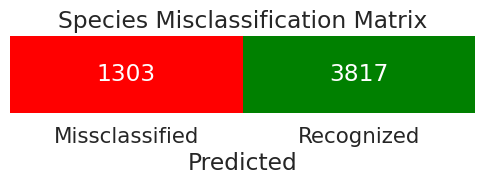

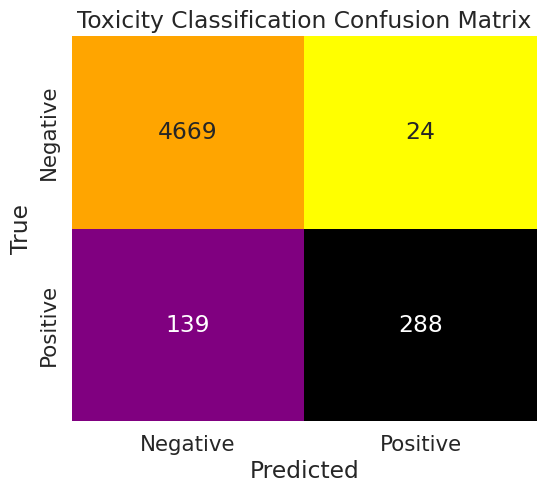


Epoch 2/4
Train Batch 1/322: Loss = 0.1034, Species Acc = 95.31%, Toxicity Acc = 100.00%
Train Batch 2/322: Loss = 0.0623, Species Acc = 98.44%, Toxicity Acc = 100.00%
Train Batch 3/322: Loss = 0.0578, Species Acc = 96.88%, Toxicity Acc = 100.00%
Train Batch 4/322: Loss = 0.1471, Species Acc = 96.88%, Toxicity Acc = 100.00%
Train Batch 5/322: Loss = 0.0260, Species Acc = 100.00%, Toxicity Acc = 98.44%
Train Batch 6/322: Loss = 0.0539, Species Acc = 96.88%, Toxicity Acc = 98.44%
Train Batch 7/322: Loss = 0.0806, Species Acc = 93.75%, Toxicity Acc = 100.00%
Train Batch 8/322: Loss = 0.0648, Species Acc = 96.88%, Toxicity Acc = 100.00%
Train Batch 9/322: Loss = 0.0137, Species Acc = 100.00%, Toxicity Acc = 100.00%
Train Batch 10/322: Loss = 0.0532, Species Acc = 98.44%, Toxicity Acc = 100.00%
Train Batch 11/322: Loss = 0.1359, Species Acc = 96.88%, Toxicity Acc = 100.00%
Train Batch 12/322: Loss = 0.0146, Species Acc = 100.00%, Toxicity Acc = 100.00%
Train Batch 13/322: Loss = 0.1098, Sp

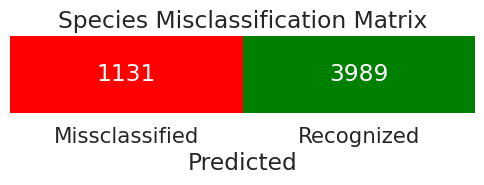

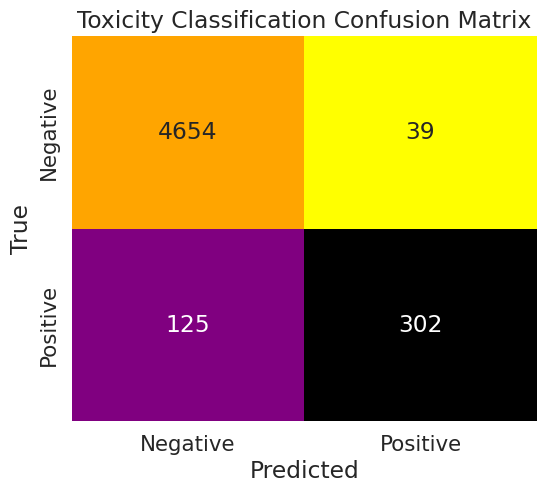


Epoch 3/4
Train Batch 1/322: Loss = 0.0306, Species Acc = 98.44%, Toxicity Acc = 100.00%
Train Batch 2/322: Loss = 0.2023, Species Acc = 98.44%, Toxicity Acc = 100.00%
Train Batch 3/322: Loss = 0.0019, Species Acc = 100.00%, Toxicity Acc = 100.00%
Train Batch 4/322: Loss = 0.0074, Species Acc = 100.00%, Toxicity Acc = 100.00%
Train Batch 5/322: Loss = 0.0169, Species Acc = 98.44%, Toxicity Acc = 100.00%
Train Batch 6/322: Loss = 0.1751, Species Acc = 96.88%, Toxicity Acc = 100.00%
Train Batch 7/322: Loss = 0.0513, Species Acc = 98.44%, Toxicity Acc = 100.00%
Train Batch 8/322: Loss = 0.1710, Species Acc = 96.88%, Toxicity Acc = 100.00%
Train Batch 9/322: Loss = 0.0348, Species Acc = 98.44%, Toxicity Acc = 100.00%
Train Batch 10/322: Loss = 0.0306, Species Acc = 98.44%, Toxicity Acc = 100.00%
Train Batch 11/322: Loss = 0.0377, Species Acc = 98.44%, Toxicity Acc = 100.00%
Train Batch 12/322: Loss = 0.0646, Species Acc = 96.88%, Toxicity Acc = 100.00%
Train Batch 13/322: Loss = 0.0427, S

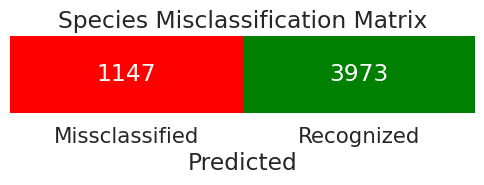

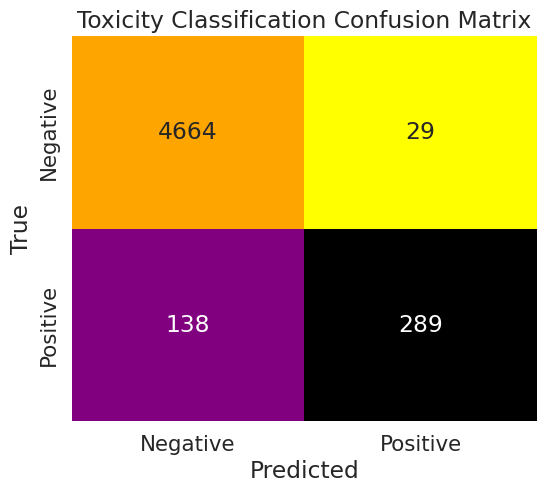


Epoch 4/4
Train Batch 1/322: Loss = 0.0327, Species Acc = 98.44%, Toxicity Acc = 100.00%
Train Batch 2/322: Loss = 0.0164, Species Acc = 100.00%, Toxicity Acc = 100.00%
Train Batch 3/322: Loss = 0.0014, Species Acc = 100.00%, Toxicity Acc = 100.00%
Train Batch 4/322: Loss = 0.0113, Species Acc = 100.00%, Toxicity Acc = 100.00%
Train Batch 5/322: Loss = 0.0037, Species Acc = 100.00%, Toxicity Acc = 100.00%
Train Batch 6/322: Loss = 0.0081, Species Acc = 100.00%, Toxicity Acc = 100.00%
Train Batch 7/322: Loss = 0.0027, Species Acc = 100.00%, Toxicity Acc = 100.00%
Train Batch 8/322: Loss = 0.0134, Species Acc = 100.00%, Toxicity Acc = 100.00%
Train Batch 9/322: Loss = 0.0005, Species Acc = 100.00%, Toxicity Acc = 100.00%
Train Batch 10/322: Loss = 0.0118, Species Acc = 100.00%, Toxicity Acc = 100.00%
Train Batch 11/322: Loss = 0.0140, Species Acc = 98.44%, Toxicity Acc = 100.00%
Train Batch 12/322: Loss = 0.0047, Species Acc = 100.00%, Toxicity Acc = 100.00%
Train Batch 13/322: Loss = 0

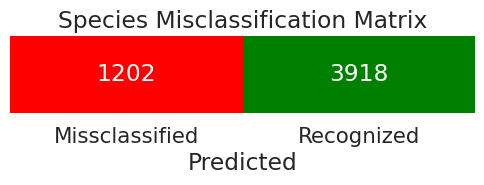

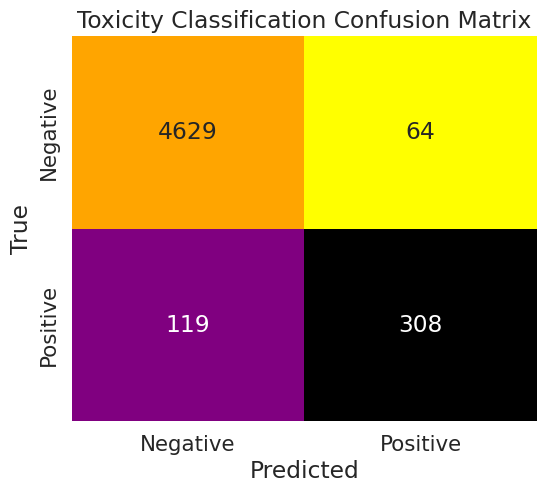

Training completed!


In [39]:
training_stats = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=num_epochs
)

torch.save(model.state_dict(), 'caformer_multitask.pth')
print("Training completed!")

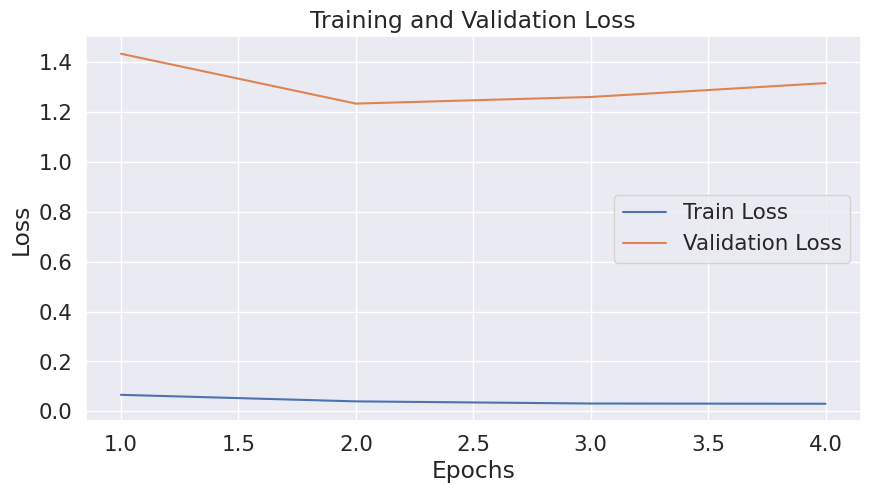

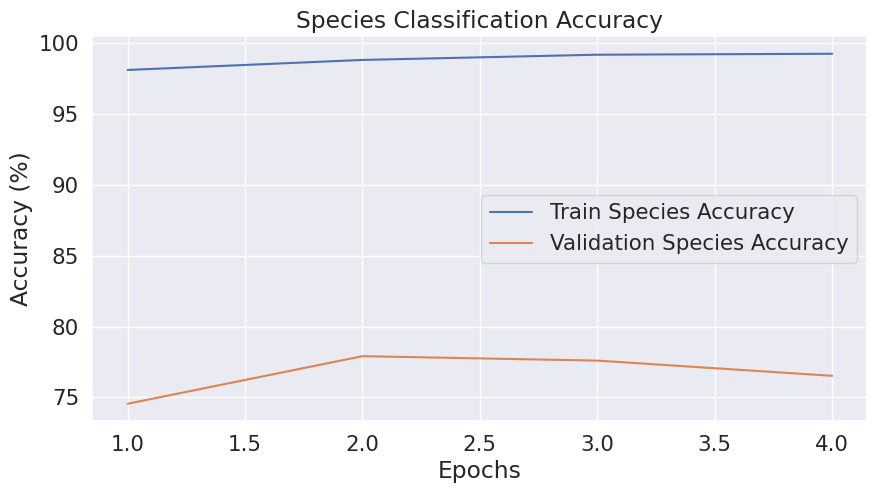

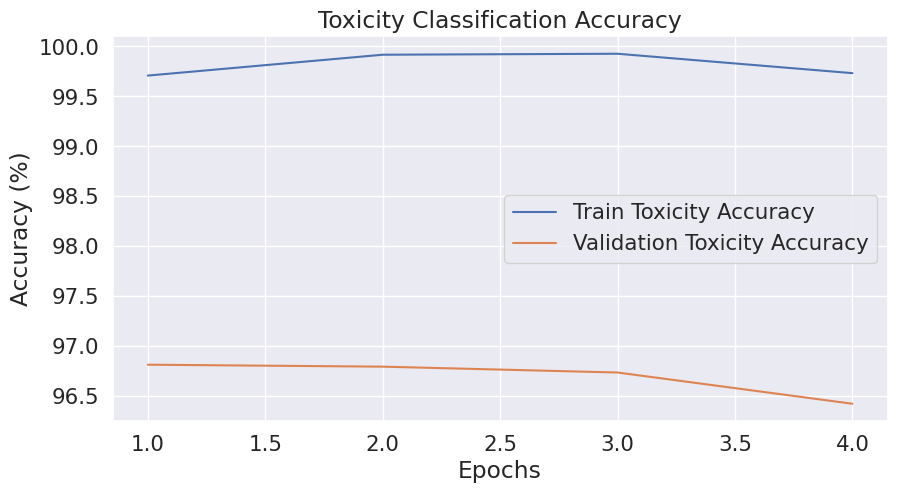

In [40]:
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs, training_stats['train_losses'], label='Train Loss')
plt.plot(epochs, training_stats['val_losses'],   label='Val Loss')
plt.xlabel('Epochs'); plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend(); plt.tight_layout()
plt.savefig('viz_caformer_loss.png', dpi=120, bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(epochs, training_stats['train_accuracies_species'], label='Train Species Acc')
plt.plot(epochs, training_stats['val_accuracies_species'],   label='Val Species Acc')
plt.xlabel('Epochs'); plt.ylabel('Accuracy (%)')
plt.title('Species Classification Accuracy')
plt.legend(); plt.tight_layout()
plt.savefig('viz_caformer_species_acc.png', dpi=120, bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(epochs, training_stats['train_accuracies_toxicity'], label='Train Toxicity Acc')
plt.plot(epochs, training_stats['val_accuracies_toxicity'],   label='Val Toxicity Acc')
plt.xlabel('Epochs'); plt.ylabel('Accuracy (%)')
plt.title('Toxicity Accuracy')
plt.legend(); plt.tight_layout()
plt.savefig('viz_caformer_tox_acc.png', dpi=120, bbox_inches='tight')
plt.show()

In [41]:
# Load best checkpoint for final evaluation and test inference
ckpt = torch.load('best_caformer.pth', map_location=device)
model.load_state_dict(ckpt['model'])
print(f"Loaded best model from epoch {ckpt['epoch']} "
      f"(val species acc = {ckpt['val_acc_species']:.2f}%)")

# ── Final val evaluation ──────────────────────────────────────────────────
model.eval()
all_preds_sp  = []; all_labels_sp  = []
all_preds_tox = []; all_labels_tox = []

with torch.no_grad():
    for images, class_ids, toxicities, _ in tqdm(val_loader, desc='Val eval', ncols=80):
        images     = images.to(device)
        outputs    = model(images)
        all_preds_sp.extend(outputs['species'].argmax(1).cpu().numpy())
        all_labels_sp.extend(class_ids.numpy())
        all_preds_tox.extend(outputs['toxicity'].argmax(1).cpu().numpy())
        all_labels_tox.extend(toxicities.numpy())

print(f"Val species  accuracy: {accuracy_score(all_labels_sp, all_preds_sp)*100:.2f}%")
print(f"Val toxicity accuracy: {accuracy_score(all_labels_tox, all_preds_tox)*100:.2f}%")
print("\nToxicity report:")
print(classification_report(all_labels_tox, all_preds_tox,
                             target_names=['Non-pois.', 'Poisonous'], zero_division=0))

# ── Test inference + submission ───────────────────────────────────────────
preds_by_obs = {}
with torch.no_grad():
    for images, filenames, obs_ids in tqdm(test_loader, desc='Test inference', ncols=80):
        images = images.to(device)
        sp_out = model(images)['species']
        probs  = F.softmax(sp_out, dim=1)

        for i, obs_id in enumerate(obs_ids):
            top_k    = torch.topk(probs[i], k=10)
            top_cls  = top_k.indices.cpu().tolist()
            top_conf = top_k.values.cpu().tolist()
            if obs_id not in preds_by_obs:
                preds_by_obs[obs_id] = {}
            for cls, conf in zip(top_cls, top_conf):
                preds_by_obs[obs_id][cls] = preds_by_obs[obs_id].get(cls, 0.0) + conf

rows = []
for obs_id, cls_scores in preds_by_obs.items():
    ranked   = sorted(cls_scores.items(), key=lambda x: x[1], reverse=True)
    pred_str = ' '.join(str(c) for c, _ in ranked[:10])
    rows.append({'observationId': obs_id, 'predictions': pred_str})

import pandas as pd
submission = pd.DataFrame(rows)
submission.to_csv('submission_caformer.csv', index=False)
print(f"\nSubmission saved — {len(submission)} observations")
print(submission.head(3).to_string())